In [ ]:
!pip install -U --user pandas ollama

In [1]:
import os
import json
import ollama
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
FRAMES_DIR = "frames"
MODEL_FILE = "model.csv"

In [3]:
image_files = [
    os.path.join(FRAMES_DIR, f)
    for f in os.listdir(FRAMES_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp"))
]

print("Found", len(image_files), "image(s)")
print(image_files[:10])

Found 182 image(s)
['frames\\bear.jpg', 'frames\\frame_0001.jpg', 'frames\\frame_0002.jpg', 'frames\\frame_0003.jpg', 'frames\\frame_0004.jpg', 'frames\\frame_0005.jpg', 'frames\\frame_0006.jpg', 'frames\\frame_0007.jpg', 'frames\\frame_0008.jpg', 'frames\\frame_0009.jpg']


In [4]:
def describe_image(image_path, model_name="ministral-3:3b"):
    response = ollama.chat(
        model=model_name,
        messages=[
            {
                "role": "user",
                "content": "Describe this animal image briefly in one sentence for image search.",
                "images": [image_path],
            }
        ],
    )
    return response["message"]["content"]

In [5]:
def get_embedding(text, model_name="embeddinggemma"):
    response = ollama.embeddings(
        model=model_name,
        prompt=text
    )
    return np.array(response["embedding"], dtype=np.float32)

In [6]:
def make_model_df():
    return pd.DataFrame(columns=["filename", "description", "embedding"])

In [9]:
def add_image_to_model(model_df, image_path, vision_model="ministral-3:3b", embedding_model="embeddinggemma"):
    description = describe_image(image_path, model_name=vision_model)
    embedding = get_embedding(description, model_name=embedding_model)

    new_row = pd.DataFrame([{
        "filename": image_path,
        "description": description,
        "embedding": embedding
    }])

    return pd.concat([model_df, new_row], ignore_index=True)

In [10]:
def find_most_similar(model_df, query_embedding):
    all_embeddings = np.vstack(model_df["embedding"].values)
    sims = cosine_similarity([query_embedding], all_embeddings)[0]
    best_idx = int(np.argmax(sims))
    return model_df.iloc[best_idx][["filename", "description"]], sims[best_idx]

In [11]:
def save_model_csv(model_df, path):
    df = model_df.copy()
    df["embedding"] = df["embedding"].apply(lambda x: json.dumps(x.tolist()))
    df.to_csv(path, index=False)

def load_model_csv(path):
    df = pd.read_csv(path)
    df["embedding"] = df["embedding"].apply(lambda x: np.array(json.loads(x), dtype=np.float32))
    return df

In [12]:
test_text = "Show me a bear"
emb = get_embedding(test_text)

print(type(emb))
print(emb.shape)

<class 'numpy.ndarray'>
(768,)


In [13]:
model = make_model_df()

sample_images = image_files[:3]
print("Using these images:")
for img in sample_images:
    print("-", img)

Using these images:
- frames\bear.jpg
- frames\frame_0001.jpg
- frames\frame_0002.jpg


In [14]:
for img_path in sample_images:
    model = add_image_to_model(model, img_path)

model[["filename", "description"]]

,filename,description
0,frames\bear.jpg,A large brown grizzly bear standing on a rocky...
1,frames\frame_0001.jpg,Aerial view of a savanna landscape with grazin...
2,frames\frame_0002.jpg,A group of zebras running and grazing in a vas...


In [15]:
save_model_csv(model, MODEL_FILE)
print("Saved model to", MODEL_FILE)

Saved model to model.csv


In [16]:
loaded_model = load_model_csv(MODEL_FILE)
loaded_model[["filename", "description"]]

,filename,description
0,frames\bear.jpg,A large brown grizzly bear standing on a rocky...
1,frames\frame_0001.jpg,Aerial view of a savanna landscape with grazin...
2,frames\frame_0002.jpg,A group of zebras running and grazing in a vas...


In [19]:
query = "Show me a zebra"
query_embedding = get_embedding(query)

result, score = find_most_similar(loaded_model, query_embedding)

print("Query:", query)
print("Best match:", result["filename"])
print("Description:", result["description"])
print("Similarity score:", score)

Query: Show me a zebra
Best match: frames\frame_0002.jpg
Description: A group of zebras running and grazing in a vast savanna landscape with dry grass, scattered trees, and a distant horizon under open skies.
Similarity score: 0.50177675


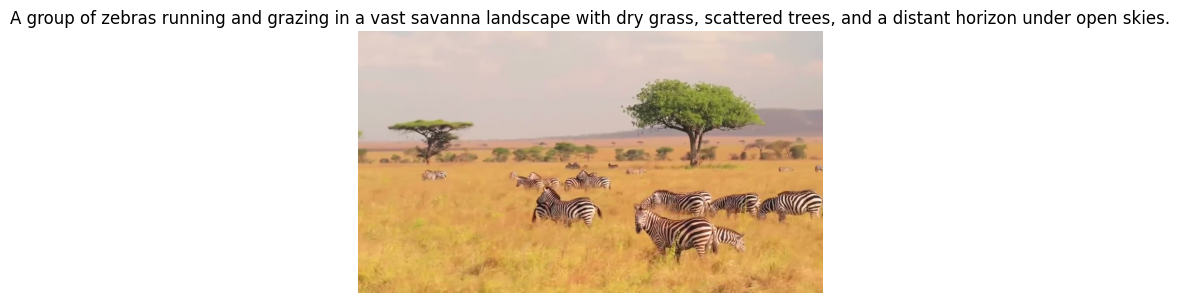

In [20]:
img = Image.open(result["filename"])

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(result["description"])
plt.show()